# Feature difficulty

In [10]:
from diagutil import *

def difficulty(ax, data=PROMPTS, categorization=TRUTH, llm='DeepSeek Coder 7B', finetune=1, lang='ocl', colors = {"Syntax Error": "#e74c3c", "Semantic Error": "#f39c12", "Correct": "#27ae60"}):
    df = data[(data['llm']==llm) & (data['finetune']==finetune) & (data['lang']==lang)].merge(categorization, left_on='caseid', right_on='id')
    df = df.explode('construct_vql')
    result = (
        df.groupby(['construct_vql', 'category'])
            .size()
            .unstack(fill_value=0)  # create columns per category
            .reset_index()
            .rename(columns={'construct_vql': 'feature'})
    )
    category_cols = result.columns.drop('feature')  # all category columns

    result_pct = result.copy()
    result_pct[category_cols] = result_pct[category_cols].div(result_pct[category_cols].sum(axis=1), axis=0) * 100

    df =  result_pct.copy()
    df.set_index('feature', inplace=True)

    for cat in ['Syntax Error', 'Semantic Error', 'Correct']:
        if cat not in df.columns:
            df[cat] = 0
    
    df[['Syntax Error','Semantic Error','Correct']].plot(
        ax = ax,
        kind='bar',
        stacked=True,
        color=[colors['Syntax Error'], colors['Semantic Error'], colors['Correct']]
    )

    # Labeling
    ax.set_title(f"{llm} (finetune: {finetune}, language: {lang})")
    ax.set_xlabel('Feature')
    ax.set_ylabel('Category %')
    ax.legend(title='Category')


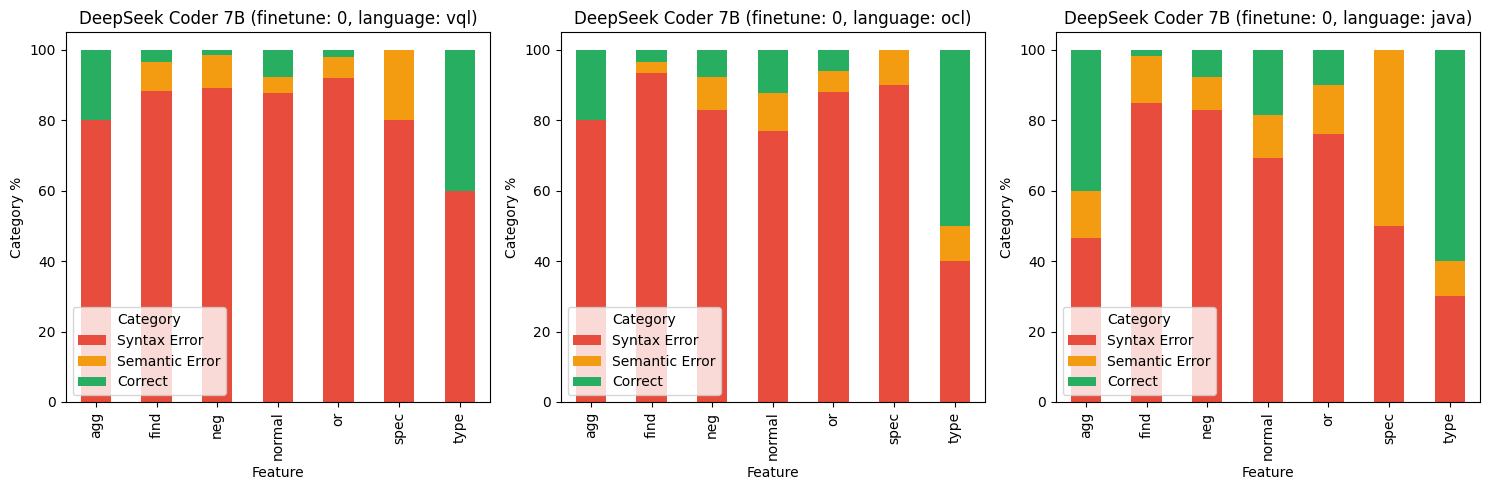

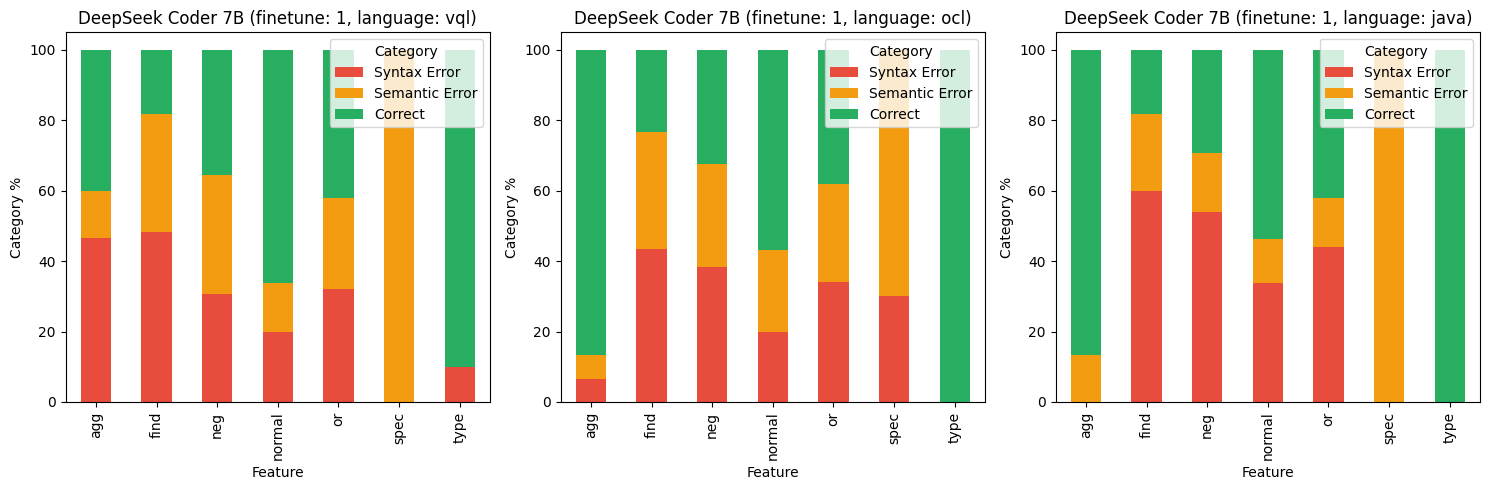

In [11]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))  # 1 row, 3 columns

for ax, lang in zip(axs, ['vql', 'ocl', 'java']):
    difficulty(ax, finetune=0, lang=lang)

plt.tight_layout()
#fig.suptitle("Feature difficulty")
plt.show()

fig, axs = plt.subplots(1, 3, figsize=(15, 5))  # 1 row, 3 columns

for ax, lang in zip(axs, ['vql', 'ocl', 'java']):
    difficulty(ax, finetune=1, lang=lang)

plt.tight_layout()
#fig.suptitle("Feature difficulty")
plt.show()

## Correctness

In [12]:
from diagutil import *

results = (
    PROMPTS.copy().groupby(["llm", "finetune", "caseid", "category", "lang"])
    .size()
    .reset_index(name="count")
)
results["finetune"] = results["finetune"].map({True: "Finetuned", False: "In context"})
totals = results.groupby(["llm", "finetune"])["count"].transform("sum")
results["x_label"] = results["caseid"].astype(str) + " - " + results["finetune"]

In [13]:
def plot_llm_subplot(ax, data, llm, language, legend=False, llmlabels=["In context", "Finetuned"], colors = {"Syntax Error": "#e74c3c", "Semantic Error": "#f39c12", "Correct": "#27ae60"}):
    subset = data[(data["llm"] == llm) & (data["lang"] == language)]

    caseids = sorted(subset["caseid"].unique())
    x = np.arange(len(caseids))
    width = 0.35

    handles = []
    labels = []

    for i, finetune_label in enumerate(llmlabels):
        sub = subset[subset["finetune"] == finetune_label]
        #pivot = sub.pivot(index="caseid", columns="category", values="count").fillna(0)

        if sub.empty:
            # Create an empty pivot to preserve structure
            pivot = pd.DataFrame(0, index=caseids, columns=["Syntax Error", "Semantic Error", "Correct"])
        else:
            pivot = sub.pivot(index="caseid", columns="category", values="count").fillna(0)
        
        bottoms = np.zeros(len(pivot))
        positions = x + (i - 0.5) * width
        
        for cat in ["Syntax Error", "Semantic Error", "Correct"]:
            values = pivot[cat].values if cat in pivot.columns else np.zeros(len(pivot))
            label = cat if cat not in labels else None
            bar = ax.bar(
                positions,
                values,
                width=width,
                bottom=bottoms,
                color=colors[cat],
                label=label
            )
            bottoms += values

            if cat not in labels:
                handles.append(bar[0])
                labels.append(cat)

    ax.axvline(x=10.5, color='blue', linestyle='--', linewidth=5)
    ax.axvline(x=16.5, color='blue', linestyle='--', linewidth=5)
    ax.axvline(x=26.5, color='blue', linestyle='--', linewidth=5)

    ax.set_title(f"LLM: {llm} {language}", fontsize=14)
    ax.set_xlim(x[0] - width - 0.05, x[-1] + width + 0.05)
    ax.set_xticks(x)
    ax.set_xticklabels([f"Case {cid}" for cid in caseids])
    ax.set_xlabel("Test Case")
    ax.set_ylabel("Number of Queries")
    if legend:
        ax.legend(title="Correctness", bbox_to_anchor=(1.05, 1), loc="upper left")

    # Add labels for Base / Finetuned
    for i, cid in enumerate(caseids):
        ax.text(x[i] - width/2, 0, "Base", ha="center", va="top", fontsize=9, color="gray")
        ax.text(x[i] + width/2, 0, "Finetuned", ha="center", va="top", fontsize=9, color="gray")

In [15]:
sns.set(style="whitegrid", palette="muted")
llms = move_to_front(results["llm"].unique(), ['GPT-5'])
n_llms = len(llms)
cases = results["caseid"].unique()
n_cases = len(cases)

fig, axes = plt.subplots(n_llms*3, 1, figsize=(2 * n_cases - 5, 18 * n_llms), sharey=True)

#if n_llms == 1:
#    axes = [axes]

for idx, llm in enumerate(llms):
    plot_llm_subplot(axes[idx*3+0], results, llm, "vql")
    plot_llm_subplot(axes[idx*3+1], results, llm, "ocl")
    plot_llm_subplot(axes[idx*3+2], results, llm, "java")

plt.tight_layout()
plt.savefig("llm_results.pdf") 
plt.show()

## Table generation

In [9]:
from diagutil import *

def remapCell(content, key='Correct'):
    ic, ft = content
    if ft:
        delta = ft[key]-ic[key]
        if delta==0:
            if ft[key]==0:
                return "\\classbothfail{}"
            if ft[key]>0:
                return "\\classbothsolve{}"
        if delta<0:
            if ft[key]==0:
                return "\\classbigfail{}"
            if ft[key]>0:
                return "\\classsmallfail{}"
        if delta>0:
            if ic[key]==0:
                return "\\classbigsuccess{}"
            if ic[key]>0:
                return "\\classsmallsuccess{}" 
    else:
        if ic[key]==0:
            return "\\classbothfail{}"
        if ic[key]>0:
            return "\\classbothsolve{}"
    return "?"
            
def remapTables(in_df):
    for lang in ['vql', 'ocl', 'java']:
        inplaceRemapTable(in_df[lang], remapCell)
        
df = makeCountTable()
remapTables(df)
df['vql']

llm,GPT-5,CodeLlama 7B,DeepSeek Coder 1.3B,DeepSeek Coder 7B,Qwen2.5 Coder 1.5B,Qwen2.5 Coder 7B,Qwen3 1.7B,Qwen3 8B
0,\classbothfail{},\classbigsuccess{},\classbigsuccess{},\classbigsuccess{},\classbigsuccess{},\classbigsuccess{},\classbigsuccess{},\classbigsuccess{}
1,\classbothfail{},\classbigsuccess{},\classbigsuccess{},\classbigsuccess{},\classbothfail{},\classbigsuccess{},\classbothfail{},\classbigsuccess{}
2,\classbothfail{},\classbigsuccess{},\classbigsuccess{},\classbigsuccess{},\classbigsuccess{},\classbigsuccess{},\classbigsuccess{},\classbigsuccess{}
3,\classbothsolve{},\classbigsuccess{},\classbigsuccess{},\classsmallsuccess{},\classbigsuccess{},\classsmallsuccess{},\classbigsuccess{},\classsmallsuccess{}
4,\classbothsolve{},\classbigsuccess{},\classbigsuccess{},\classsmallsuccess{},\classbigsuccess{},\classsmallsuccess{},\classbigsuccess{},\classsmallsuccess{}
5,\classbothsolve{},\classsmallsuccess{},\classbigsuccess{},\classsmallsuccess{},\classsmallsuccess{},\classsmallsuccess{},\classsmallsuccess{},\classsmallsuccess{}
6,\classbothsolve{},\classbigsuccess{},\classbigsuccess{},\classbigsuccess{},\classbothfail{},\classbigsuccess{},\classbigsuccess{},\classbigsuccess{}
7,\classbothsolve{},\classsmallsuccess{},\classbigsuccess{},\classbigsuccess{},\classbigsuccess{},\classbigsuccess{},\classbothfail{},\classbigsuccess{}
8,\classbothfail{},\classbothfail{},\classbothfail{},\classbothfail{},\classbothfail{},\classbothfail{},\classbothfail{},\classbothfail{}
9,\classbothsolve{},\classbigsuccess{},\classbigsuccess{},\classbigsuccess{},\classbigsuccess{},\classbigsuccess{},\classbigsuccess{},\classbigsuccess{}


In [11]:
from diagutil import *
        
def generateTable(tables, langs=['vql', 'ocl', 'java'], indicator={'vql':'VQL', 'ocl':'OCL', 'java':'Java'}):
    result = "\\hfill\n"
    for lang in langs:
        table = tables[lang].copy()
        table.columns = [f"\\rotatebox{{90}}{{{col}}}" for col in table.columns]

        result += replaceFirstCell(table.to_latex(
            index=True,          # include LLM names as row labels
            escape=False,        # let special chars like + or : through
            column_format="l" + "c" * len(table.columns)  # nice column alignment
        ), indicator[lang], hline=r'^(17|27)\b', hdashline=r'^(11)\b')
        result += "\\hfill\n"
    return result


print(generateTable(df))

\hfill
\begin{tabular}{lcccccccc}
\toprule
\rotatebox{90}{\textbf{VQL}} & \rotatebox{90}{GPT-5} & \rotatebox{90}{CodeLlama 7B} & \rotatebox{90}{DeepSeek Coder 1.3B} & \rotatebox{90}{DeepSeek Coder 7B} & \rotatebox{90}{Qwen2.5 Coder 1.5B} & \rotatebox{90}{Qwen2.5 Coder 7B} & \rotatebox{90}{Qwen3 1.7B} & \rotatebox{90}{Qwen3 8B} \\
\midrule
0 & \classbothfail{} & \classbigsuccess{} & \classbigsuccess{} & \classbigsuccess{} & \classbigsuccess{} & \classbigsuccess{} & \classbigsuccess{} & \classbigsuccess{} \\
1 & \classbothfail{} & \classbigsuccess{} & \classbigsuccess{} & \classbigsuccess{} & \classbothfail{} & \classbigsuccess{} & \classbothfail{} & \classbigsuccess{} \\
2 & \classbothfail{} & \classbigsuccess{} & \classbigsuccess{} & \classbigsuccess{} & \classbigsuccess{} & \classbigsuccess{} & \classbigsuccess{} & \classbigsuccess{} \\
3 & \classbothsolve{} & \classbigsuccess{} & \classbigsuccess{} & \classsmallsuccess{} & \classbigsuccess{} & \classsmallsuccess{} & \classbigsuccess{

## Result 1
How much finetuning improves the correctness of generated queries?


In [6]:
from diagutil import *

def aggregateColumn(column):
    accu_ic = 0
    accu_ft = 0;
    for ic, ft in column:
        if ic['Correct']>=1:
            accu_ic+=1
        if ft and ft['Correct']>=1:
            accu_ft+=1
    delta = (accu_ft-accu_ic)
    return accu_ic, accu_ft , f"+{delta}" if delta>=0 else f"{delta}"

def process(content, lang):
    match_tab = re.search(r'\\begin{tabular}.*?\\end{tabular}', content, re.DOTALL)
    if match_tab:
        text = re.sub(r'(^\\toprule\n)(^ )(&)', lambda match : match.group(1)+f"\\rotatebox{{90}}{{\\textbf{{{lang}}}}} "+match.group(3), match_tab.group(), flags=re.MULTILINE )
        return re.sub(r'^(11|17|27)\b', lambda match : f"\\hline\n"+match.group(1), text, flags=re.MULTILINE)     
    else:
        return content
        
def generateTable2(tables, langs=['vql', 'ocl', 'java'], indicator={'vql':'VQL', 'ocl':'OCL', 'java':'Java'}):
    result = "\\hfill\n"
    for lang in langs:
        table = tables[lang].copy().drop('GPT-5', axis=1).aggregate(aggregateColumn)
        table.columns = [f"\\rotatebox{{90}}{{{col}}}" for col in table.columns]

        table.rename(index={0: "IC", 1: "FT", 2: "$\\Delta$"}, inplace=True)
        result += process(table.to_latex(
            index=True,          # include LLM names as row labels
            escape=False,        # let special chars like + or : through
            column_format="l" + "c" * len(table.columns)  # nice column alignment
        ), indicator[lang])
        result += "\\hfill\n"
    return result


dfs = makeCountTable()

print(generateTable2(dfs))

\hfill
\begin{tabular}{lccccccc}
\toprule
\rotatebox{90}{\textbf{VQL}} & \rotatebox{90}{CodeLlama 7B} & \rotatebox{90}{DeepSeek Coder 1.3B} & \rotatebox{90}{DeepSeek Coder 7B} & \rotatebox{90}{Qwen2.5 Coder 1.5B} & \rotatebox{90}{Qwen2.5 Coder 7B} & \rotatebox{90}{Qwen3 1.7B} & \rotatebox{90}{Qwen3 8B} \\
\midrule
IC & 6 & 1 & 10 & 6 & 10 & 4 & 8 \\
FT & 26 & 23 & 26 & 21 & 27 & 19 & 28 \\
$\Delta$ & +20 & +22 & +16 & +15 & +17 & +15 & +20 \\
\bottomrule
\end{tabular}\hfill
\begin{tabular}{lccccccc}
\toprule
\rotatebox{90}{\textbf{OCL}} & \rotatebox{90}{CodeLlama 7B} & \rotatebox{90}{DeepSeek Coder 1.3B} & \rotatebox{90}{DeepSeek Coder 7B} & \rotatebox{90}{Qwen2.5 Coder 1.5B} & \rotatebox{90}{Qwen2.5 Coder 7B} & \rotatebox{90}{Qwen3 1.7B} & \rotatebox{90}{Qwen3 8B} \\
\midrule
IC & 8 & 3 & 12 & 4 & 15 & 4 & 9 \\
FT & 20 & 19 & 20 & 18 & 19 & 18 & 17 \\
$\Delta$ & +12 & +16 & +8 & +14 & +4 & +14 & +8 \\
\bottomrule
\end{tabular}\hfill
\begin{tabular}{lccccccc}
\toprule
\rotatebox{90}{\t

## Result 2
How close the finetuned (or in-context) models are to ChatGPT 5.

In [8]:
from diagutil import *

def aggregateColumn(column):
    accu_ic = 0
    accu_ft = 0;
    for ic, ft in column:
        if ic['Correct']>=1:
            accu_ic+=1
        if ft and ft['Correct']>=1:
            accu_ft+=1
    delta = (accu_ft-accu_ic)
    return accu_ic, accu_ft , f"+{delta}" if delta>=0 else f"{delta}"


        
def generateTable2(tables, langs=['vql', 'ocl', 'java'], indicator={'vql':'VQL', 'ocl':'OCL', 'java':'Java'}):
    result = "\\hfill\n"
    for lang in langs:
        table = tables[lang].copy()
        gptcount, _, _ = aggregateColumn(table['GPT-5'])
        table = table.aggregate(aggregateColumn)

        perf = table.loc[1].copy()
        perf['GPT-5'] = table.loc[0, 'GPT-5']

        delta = perf.copy()
        cols = [col for col in table.columns if not col in [indicator[lang], 'GPT-5']]
        delta[cols] = delta[cols] - gptcount
        delta['GPT-5'] = ''

        table = pd.DataFrame([perf, delta]).reset_index().drop('index', axis=1)
        table.columns = [f"\\rotatebox{{90}}{{{col}}}" for col in table.columns]
        table.rename(index={0: "$\\Sigma$", 1: "$\\Delta$"}, inplace=True)
        result += replaceFirstCell(table.to_latex(
            index=True,          # include LLM names as row labels
            escape=False,        # let special chars like + or : through
            column_format="l" + "c" * len(table.columns)  # nice column alignment
        ), indicator[lang], hline=r'^(11|17|27)\b')
        result += "\\hfill\n"
    return result

        

dfs = makeCountTable()
generateTable2(dfs)
print(generateTable2(dfs))

\hfill
\begin{tabular}{lcccccccc}
\toprule
\rotatebox{90}{\textbf{VQL}} & \rotatebox{90}{GPT-5} & \rotatebox{90}{CodeLlama 7B} & \rotatebox{90}{DeepSeek Coder 1.3B} & \rotatebox{90}{DeepSeek Coder 7B} & \rotatebox{90}{Qwen2.5 Coder 1.5B} & \rotatebox{90}{Qwen2.5 Coder 7B} & \rotatebox{90}{Qwen3 1.7B} & \rotatebox{90}{Qwen3 8B} \\
\midrule
$\Sigma$ & 26 & 26 & 23 & 26 & 21 & 27 & 19 & 28 \\
$\Delta$ &  & 0 & -3 & 0 & -5 & 1 & -7 & 2 \\
\bottomrule
\end{tabular}\hfill
\begin{tabular}{lcccccccc}
\toprule
\rotatebox{90}{\textbf{OCL}} & \rotatebox{90}{GPT-5} & \rotatebox{90}{CodeLlama 7B} & \rotatebox{90}{DeepSeek Coder 1.3B} & \rotatebox{90}{DeepSeek Coder 7B} & \rotatebox{90}{Qwen2.5 Coder 1.5B} & \rotatebox{90}{Qwen2.5 Coder 7B} & \rotatebox{90}{Qwen3 1.7B} & \rotatebox{90}{Qwen3 8B} \\
\midrule
$\Sigma$ & 21 & 20 & 19 & 20 & 18 & 19 & 18 & 17 \\
$\Delta$ &  & -1 & -2 & -1 & -3 & -2 & -3 & -4 \\
\bottomrule
\end{tabular}\hfill
\begin{tabular}{lcccccccc}
\toprule
\rotatebox{90}{\textbf{Ja

## Result 3
How well does LLMs perform?

In [8]:
from diagutil import *

def presentData(cell):
    return cell

bins = [-1, 10, 16, 26, 38]
labels = ['Text2VQL', 'Railway', 'DLT', 'CPS']

def aggregateColumn(column):
    accu_ic = 0
    accu_ft = 0;
    for ic, ft in column:
        if ic['Correct']>=1:
            accu_ic+=1
        if ft and ft['Correct']>=1:
            accu_ft+=1
    delta = (accu_ft-accu_ic)
    return accu_ic, accu_ft , f"+{delta}" if delta>=0 else f"{delta}"


        
def generateTable2(tables, langs=['vql', 'ocl', 'java'], indicator={'vql':'VQL', 'ocl':'OCL', 'java':'Java'}):
    result = "\\hfill\n"
    for lang in langs:
        table = tables[lang].copy().reset_index()
        dataframes = []
        table['index_bin'] = pd.cut(table['index'], bins=bins, labels=labels, right=True)
        for gname, gdata in table.groupby('index_bin', observed=True):
            gdata.drop("index", axis=1, inplace=True)
            gdata.drop("index_bin", axis=1, inplace=True)
            
            gptcount, _, _ = aggregateColumn(gdata['GPT-5'])
            table = gdata.aggregate(aggregateColumn)
            table.loc[1, 'GPT-5'] = ""
            table.loc[2, 'GPT-5'] = ""
            table.rename(index={0: f"{gname} $\\Sigma$ IC ", 1: f"{gname} $\\Sigma$ FT ", 2: f"{gname} $\\Delta$"}, inplace=True)

            dataframes.append(table)
        
        table = pd.concat(dataframes)
        table.columns = [f"\\rotatebox{{90}}{{{col}}}" for col in table.columns]
        result += replaceFirstCell(table.to_latex(
                index=True,          # include LLM names as row labels
                escape=False,        # let special chars like + or : through
                column_format="l" + "c" * len(table.columns)  # nice column alignment
        ), lang, hline=r'^((?:DLT|CPS).*IC)\b', hdashline=r'^((?:Railway).*IC)\b')#), lang, hline=r'^(DLT \$\\Sigma\$ IC|CPS \$\\Sigma\$ IC|Railway \$\\Sigma\$ IC|)\b')
        result += "\\hfill\n"
    return result

        

dfs = makeCountTable()
data = generateTable2(dfs)
#print(generateTable2(dfs))
print(data)

\hfill
\begin{tabular}{lcccccccc}
\toprule
\rotatebox{90}{\textbf{vql}} & \rotatebox{90}{GPT-5} & \rotatebox{90}{CodeLlama 7B} & \rotatebox{90}{DeepSeek Coder 1.3B} & \rotatebox{90}{DeepSeek Coder 7B} & \rotatebox{90}{Qwen2.5 Coder 1.5B} & \rotatebox{90}{Qwen2.5 Coder 7B} & \rotatebox{90}{Qwen3 1.7B} & \rotatebox{90}{Qwen3 8B} \\
\midrule
Text2VQL $\Sigma$ IC  & 6 & 2 & 0 & 3 & 1 & 3 & 1 & 3 \\
Text2VQL $\Sigma$ FT  &  & 9 & 10 & 9 & 7 & 9 & 7 & 10 \\
Text2VQL $\Delta$ &  & +7 & +10 & +6 & +6 & +6 & +6 & +7 \\
\hdashline
Railway $\Sigma$ IC  & 5 & 2 & 1 & 2 & 2 & 3 & 3 & 2 \\
Railway $\Sigma$ FT  &  & 4 & 2 & 3 & 3 & 4 & 2 & 5 \\
Railway $\Delta$ &  & +2 & +1 & +1 & +1 & +1 & -1 & +3 \\
\hline
DLT $\Sigma$ IC  & 8 & 1 & 0 & 3 & 1 & 1 & 0 & 0 \\
DLT $\Sigma$ FT  &  & 5 & 4 & 7 & 3 & 6 & 3 & 6 \\
DLT $\Delta$ &  & +4 & +4 & +4 & +2 & +5 & +3 & +6 \\
\hline
CPS $\Sigma$ IC  & 7 & 1 & 0 & 2 & 2 & 3 & 0 & 3 \\
CPS $\Sigma$ FT  &  & 8 & 7 & 7 & 8 & 8 & 7 & 7 \\
CPS $\Delta$ &  & +7 & +7 & +5

## Result 4
How well does the approach generalize for diffferent domains?

In [24]:
from diagutil import *

def aggregateColumn(column):
    accu_ic = 0
    accu_ft = 0;
    for ic, ft in column:
        if ic['Correct']>=1:
            accu_ic+=1
        if ft and ft['Correct']>=1:
            accu_ft+=1
    delta = (accu_ft-accu_ic)
    return accu_ic, accu_ft , f"+{delta}" if delta>=0 else f"{delta}"

def process(content, lang):
    match_tab = re.search(r'\\begin{tabular}.*?\\end{tabular}', content, re.DOTALL)
    if match_tab:
        text = re.sub(r'(^\\toprule\n)(^ )(&)', lambda match : match.group(1)+f"\\rotatebox{{90}}{{\\textbf{{{lang}}}}} "+match.group(3), match_tab.group(), flags=re.MULTILINE )
        return re.sub(r'^(11|17|27)\b', lambda match : f"\\hline\n"+match.group(1), text, flags=re.MULTILINE)     
    else:
        return content
        
def generateTable2(tables, langs=['vql', 'ocl', 'java'], indicator={'vql':'VQL', 'ocl':'OCL', 'java':'Java'}):
    result = "\\hfill\n"
    for lang in langs:
        table = tables[lang].copy().transpose()
        table = table.aggregate(aggregateColumn)
        table.rename(index={0: 'IC', 1: 'FT', 2: "$\\Delta$"}, inplace=True)
        table = table.transpose()
        #table.columns = [f"\\rotatebox{{90}}{{{col}}}" for col in table.columns]

        result += replaceFirstCell(table.to_latex(
            index=True,          # include LLM names as row labels
            escape=False,        # let special chars like + or : through
            column_format="|l" + "c" * len(table.columns)+"|"  # nice column alignment
        ), indicator[lang], hline=r'^(17|27)\b', hdashline=r'^(11)\b')
        result += "\\hfill\n"
    return result


dfs = makeCountTable()

print(generateTable2(dfs))

\hfill
\begin{tabular}{|lccc|}
\toprule
\rotatebox{90}{\textbf{VQL}} & IC & FT & $\Delta$ \\
\midrule
0 & 0 & 7 & +7 \\
1 & 0 & 5 & +5 \\
2 & 0 & 7 & +7 \\
3 & 4 & 7 & +3 \\
4 & 4 & 7 & +3 \\
5 & 7 & 7 & +0 \\
6 & 1 & 6 & +5 \\
7 & 2 & 6 & +4 \\
8 & 0 & 0 & +0 \\
9 & 1 & 7 & +6 \\
10 & 0 & 2 & +2 \\
\hline
11 & 1 & 1 & +0 \\
12 & 6 & 4 & -2 \\
13 & 6 & 7 & +1 \\
14 & 1 & 4 & +3 \\
15 & 5 & 7 & +2 \\
16 & 1 & 0 & -1 \\
\hline
17 & 3 & 7 & +4 \\
18 & 1 & 3 & +2 \\
19 & 1 & 5 & +4 \\
20 & 1 & 2 & +1 \\
21 & 0 & 0 & +0 \\
22 & 2 & 6 & +4 \\
24 & 1 & 4 & +3 \\
25 & 1 & 0 & -1 \\
26 & 4 & 7 & +3 \\
\hline
27 & 0 & 5 & +5 \\
28 & 4 & 7 & +3 \\
29 & 2 & 7 & +5 \\
30 & 5 & 7 & +2 \\
31 & 0 & 0 & +0 \\
32 & 0 & 0 & +0 \\
33 & 2 & 5 & +3 \\
34 & 2 & 7 & +5 \\
35 & 1 & 7 & +6 \\
36 & 0 & 0 & +0 \\
37 & 2 & 7 & +5 \\
38 & 0 & 0 & +0 \\
\bottomrule
\end{tabular}\hfill
\begin{tabular}{|lccc|}
\toprule
\rotatebox{90}{\textbf{OCL}} & IC & FT & $\Delta$ \\
\midrule
0 & 5 & 7 & +2 \\
1 & 0 & 0 & +0 \\
2 

# Dataset generation cost

In [1]:
from diagutil import *
alltokens = countTokens()
print(alltokens)
print(toUSD(alltokens, discount=0.5))

{'input': 13182748, 'cached': 2197760, 'output': 7426117}
{'input': 8.2392175, 'cached': 0.13736, 'output': 37.130585, 'total': 45.369802500000006}


In [2]:
from diagutil import *
alltokens = countTokensPerLanguage()
print(alltokens)
print(toUSD(alltokens, discount=0.5))

{'vql': {'input': 3917269, 'cached': 1280, 'output': 1705158}, 'ocl': {'input': 3856050, 'cached': 0, 'output': 1511192}, 'java': {'input': 5409429, 'cached': 2196480, 'output': 4209767}}
{'vql': {'input': 2.448293125, 'cached': 8e-05, 'output': 8.52579, 'total': 10.974083125}, 'ocl': {'input': 2.41003125, 'cached': 0.0, 'output': 7.55596, 'total': 9.96599125}, 'java': {'input': 3.380893125, 'cached': 0.13728, 'output': 21.048835, 'total': 24.429728125}}
